In [1]:
%pip install -q scikit-learn scipy matplotlib


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 4)
plt.style.use("seaborn-v0_8-whitegrid")


def plot_cluster_map(points_2d, labels, title, axis=None, x_label="Component 1", y_label="Component 2"):
    if axis is None:
        axis = plt.gca()

    unique_labels = sorted(np.unique(labels))
    palette = plt.get_cmap("tab10")
    color_index = 0

    for label in unique_labels:
        mask = labels == label
        if label == -1:
            axis.scatter(
                points_2d[mask, 0],
                points_2d[mask, 1],
                color="black",
                s=45,
                alpha=0.85,
                label="noise",
            )
        else:
            axis.scatter(
                points_2d[mask, 0],
                points_2d[mask, 1],
                color=palette(color_index % 10),
                s=45,
                alpha=0.85,
                label=f"cluster {label}",
            )
            color_index += 1

    axis.set_title(title)
    axis.set_xlabel(x_label)
    axis.set_ylabel(y_label)
    axis.legend()
    axis.grid(alpha=0.25)


def silhouette_details(features, labels):
    unique_labels = np.unique(labels)
    if len(unique_labels) < 2 or len(unique_labels) >= len(labels):
        return np.full(len(labels), np.nan), np.nan

    sample_scores = silhouette_samples(features, labels)
    average_score = silhouette_score(features, labels)
    return sample_scores, float(average_score)


def describe_clustering(features, labels, model_name):
    sample_scores, average_score = silhouette_details(features, labels)
    row = {
        "model": model_name,
        "cluster_count": int(len(set(labels)) - (1 if -1 in labels else 0)),
        "noise_points": int(np.sum(labels == -1)),
        "silhouette_score": average_score,
    }
    return row, sample_scores


def estimate_eps_from_k_distance(sorted_distances):
    x_values = np.arange(len(sorted_distances), dtype=float)
    points = np.column_stack((x_values, sorted_distances))
    start = points[0]
    end = points[-1]
    line_vector = end - start
    line_vector = line_vector / np.linalg.norm(line_vector)

    projected_points = start + np.outer((points - start) @ line_vector, line_vector)
    distances_to_line = np.linalg.norm(points - projected_points, axis=1)
    elbow_index = int(np.argmax(distances_to_line))
    return float(sorted_distances[elbow_index]), elbow_index


In [3]:
from sklearn.datasets import load_iris

# Load the classic Iris dataset for our clustering analysis
iris_bundle = load_iris(as_frame=True)
iris_features = iris_bundle.data.copy()
iris_target = iris_bundle.target.copy()
iris_names = iris_bundle.target_names

# Standardize features: essential for distance-based algorithms like Hierarchical/DBSCAN
scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(iris_features)

# Reduce dimensionality to 2D for visualization purposes
pca = PCA(n_components=2)
X_iris_pca = pca.fit_transform(X_iris_scaled)

print("Original Iris feature shape:", iris_features.shape)
print("Scaled feature shape:", X_iris_scaled.shape)
display(iris_features.head())

Original Iris feature shape: (150, 4)
Scaled feature shape: (150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


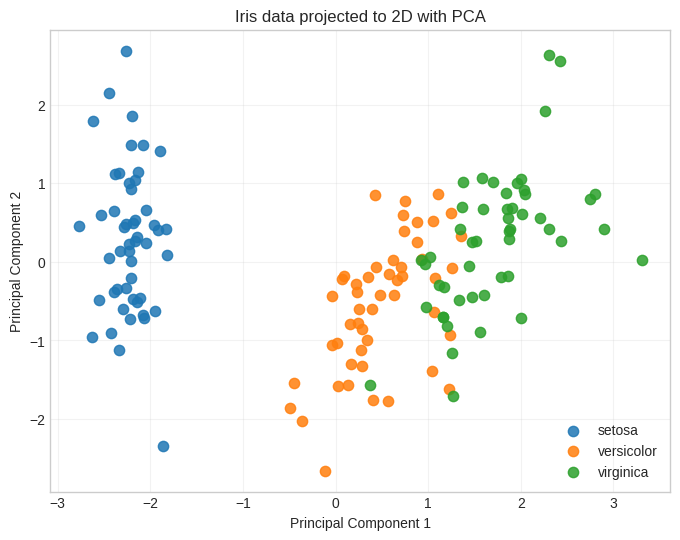

In [4]:
plt.figure(figsize=(8, 6))

for class_id, class_name in enumerate(iris_names):
    mask = iris_target.to_numpy() == class_id
    plt.scatter(
        X_iris_pca[mask, 0],
        X_iris_pca[mask, 1],
        s=55,
        alpha=0.85,
        label=class_name,
    )

plt.title("Iris data projected to 2D with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


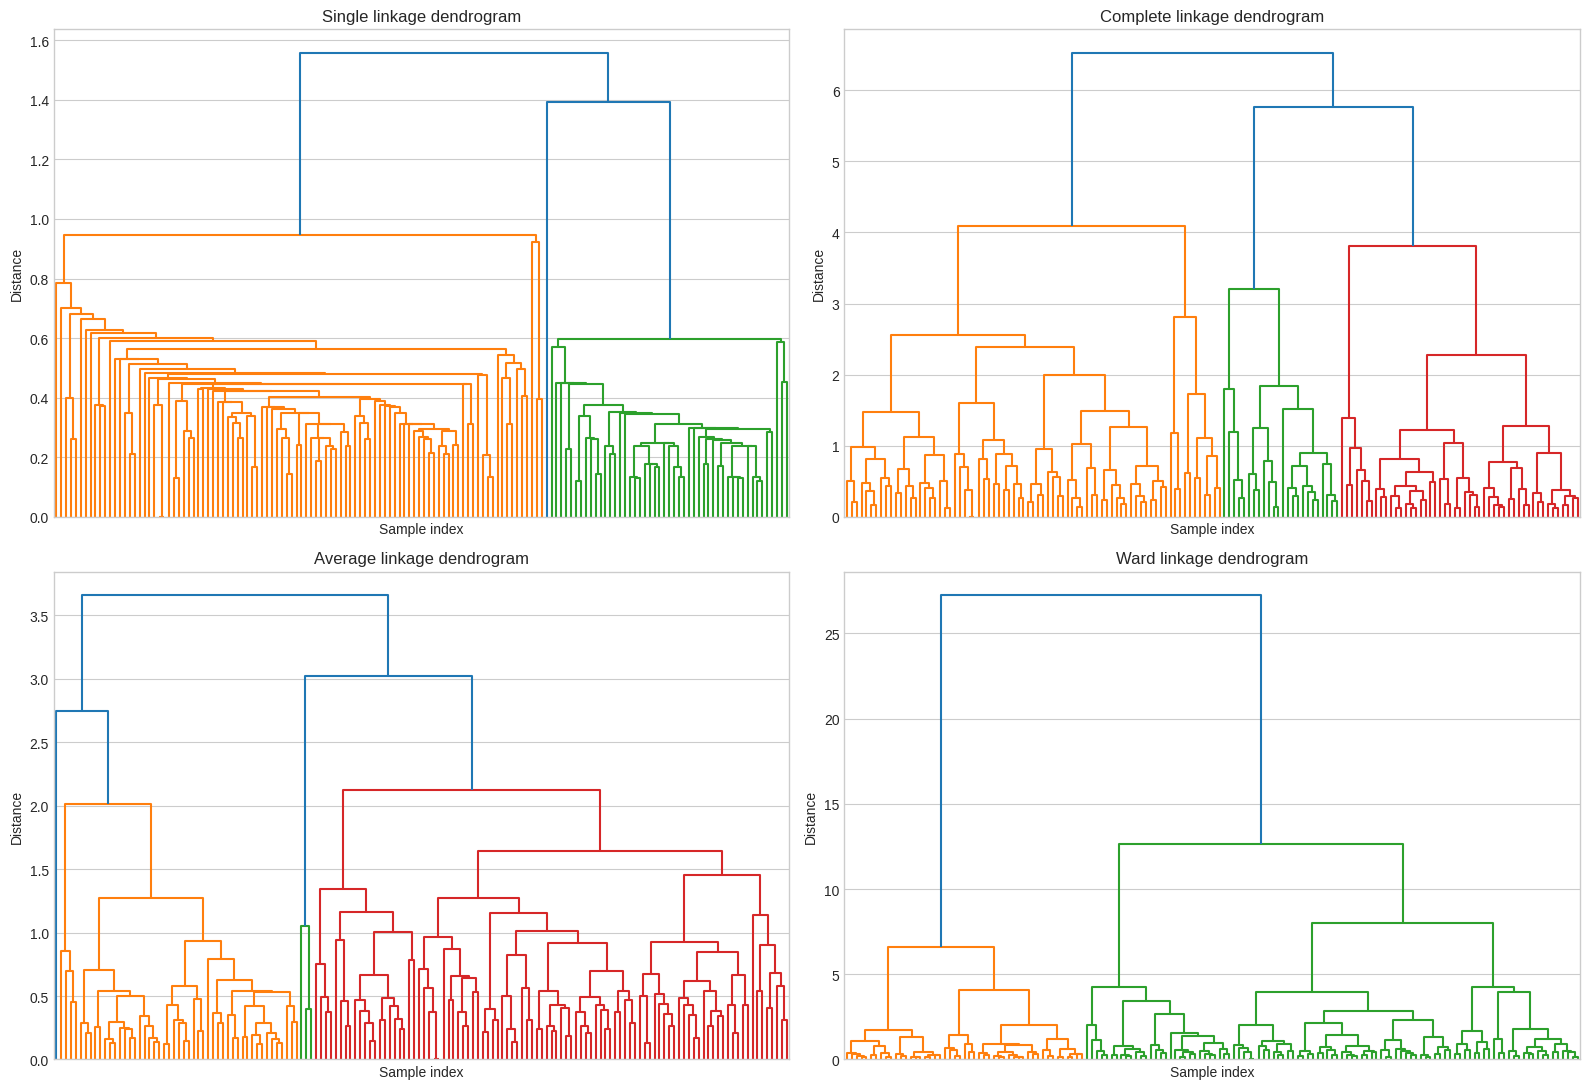

In [5]:
# We test different linkage criteria to see how they merge clusters
linkage_methods = ["single", "complete", "average", "ward"]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

for axis, method in zip(axes.ravel(), linkage_methods):
    # Calculate the linkage matrix (the 'tree' of merges)
    linkage_matrix = linkage(X_iris_scaled, method=method)
    # Plot the dendrogram to visualize the hierarchical structure
    dendrogram(linkage_matrix, ax=axis, no_labels=True, color_threshold=None)
    axis.set_title(f"{method.title()} linkage dendrogram")
    axis.set_xlabel("Sample index")
    axis.set_ylabel("Distance")

plt.tight_layout()
plt.show()

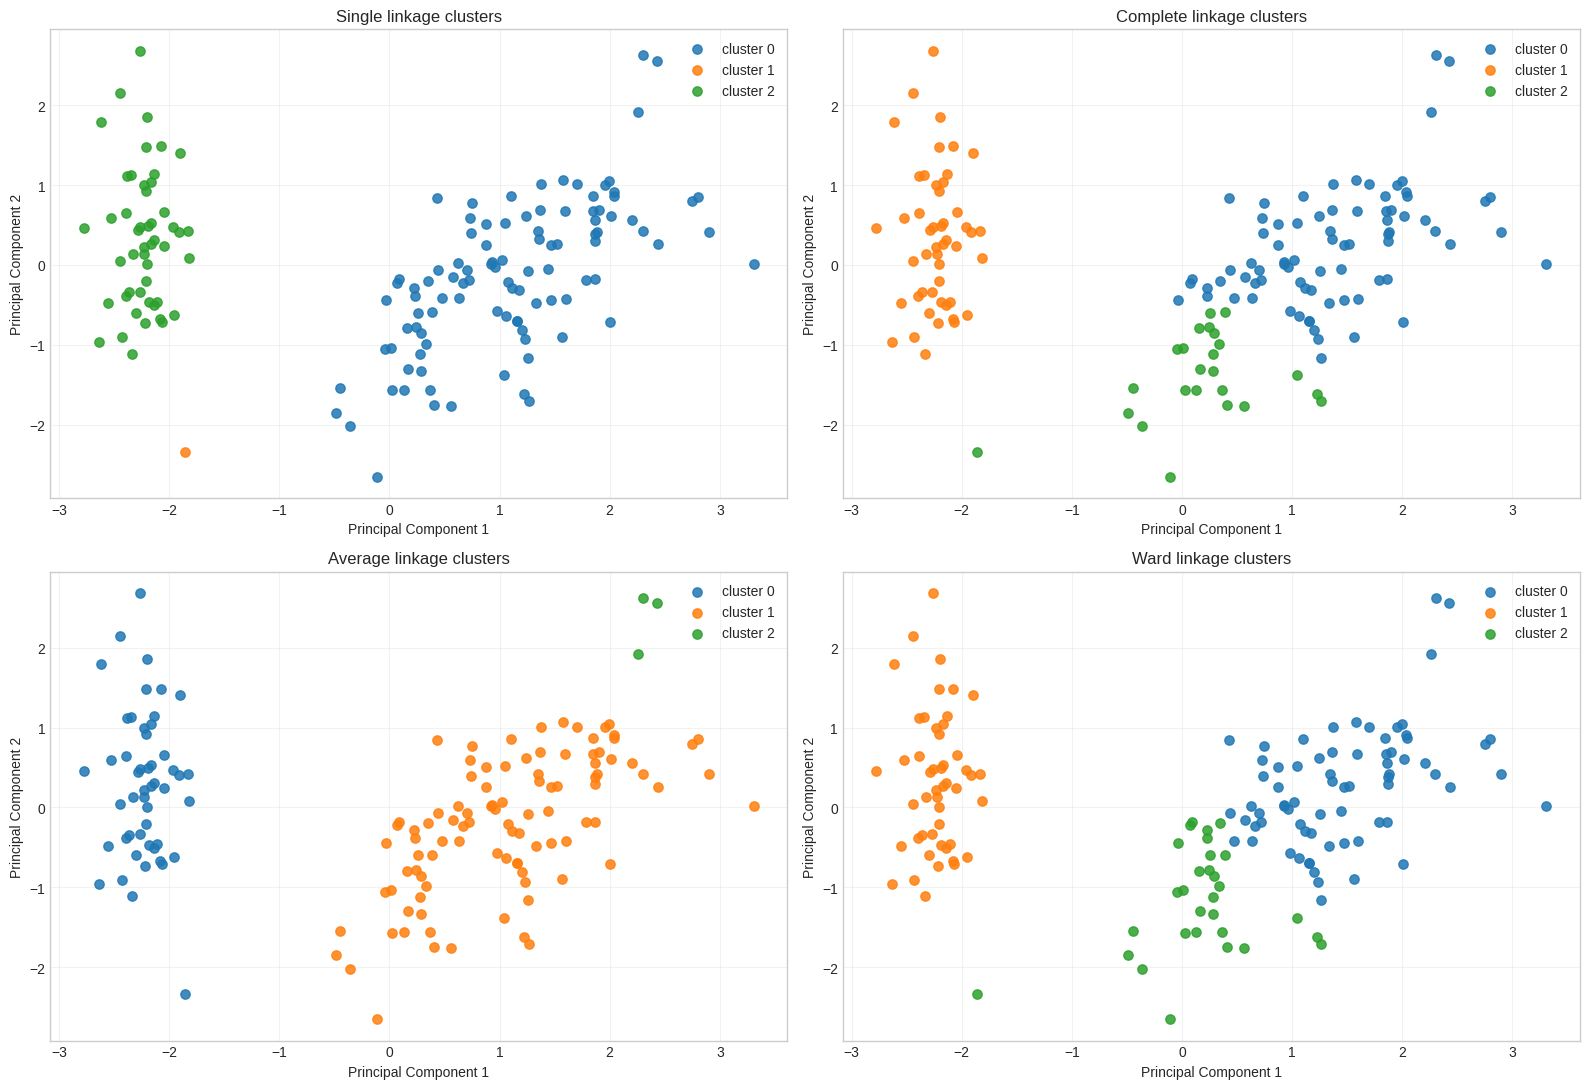

,model,cluster_count,noise_points,silhouette_score
0,Hierarchical - single,3,0,0.5046
2,Hierarchical - average,3,0,0.4803
1,Hierarchical - complete,3,0,0.4496
3,Hierarchical - ward,3,0,0.4467


In [6]:
hierarchical_rows_iris = []
hierarchical_sample_scores_iris = {}
hierarchical_labels_iris = {}

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

for axis, method in zip(axes.ravel(), linkage_methods):
    model = AgglomerativeClustering(n_clusters=3, linkage=method)
    labels = model.fit_predict(X_iris_scaled)

    hierarchical_labels_iris[method] = labels
    plot_cluster_map(
        X_iris_pca,
        labels,
        title=f"{method.title()} linkage clusters",
        axis=axis,
        x_label="Principal Component 1",
        y_label="Principal Component 2",
    )

    row, sample_scores = describe_clustering(
        X_iris_scaled,
        labels,
        model_name=f"Hierarchical - {method}",
    )
    hierarchical_rows_iris.append(row)
    hierarchical_sample_scores_iris[f"{method}_sample_silhouette"] = sample_scores

plt.tight_layout()
plt.show()

hierarchical_results_iris = pd.DataFrame(hierarchical_rows_iris).sort_values(
    by="silhouette_score",
    ascending=False,
)
display(hierarchical_results_iris)


In [7]:
hierarchical_silhouette_df_iris = pd.DataFrame(hierarchical_sample_scores_iris)
display(hierarchical_silhouette_df_iris.head(10))
display(hierarchical_silhouette_df_iris.describe().T[["mean", "min", "max"]])


,single_sample_silhouette,complete_sample_silhouette,average_sample_silhouette,ward_sample_silhouette
0,0.7153,0.7438,0.7605,0.7340
1,0.2934,0.5225,0.6395,0.5171
2,0.5363,0.6607,0.7227,0.6533
3,0.3973,0.5882,0.6789,0.5815
4,0.7131,0.7400,0.7527,0.7299
5,0.6424,0.6396,0.6266,0.6222
6,0.6267,0.6960,0.7343,0.6863
7,0.6949,0.7352,0.7617,0.7258
8,-0.1006,0.4117,0.5747,0.4121
9,0.4539,0.6044,0.6874,0.5974


,mean,min,max
single_sample_silhouette,0.5046,-0.3825,0.7153
complete_sample_silhouette,0.4496,-0.2989,0.7438
average_sample_silhouette,0.4803,-0.2350,0.7945
ward_sample_silhouette,0.4467,-0.2304,0.7340


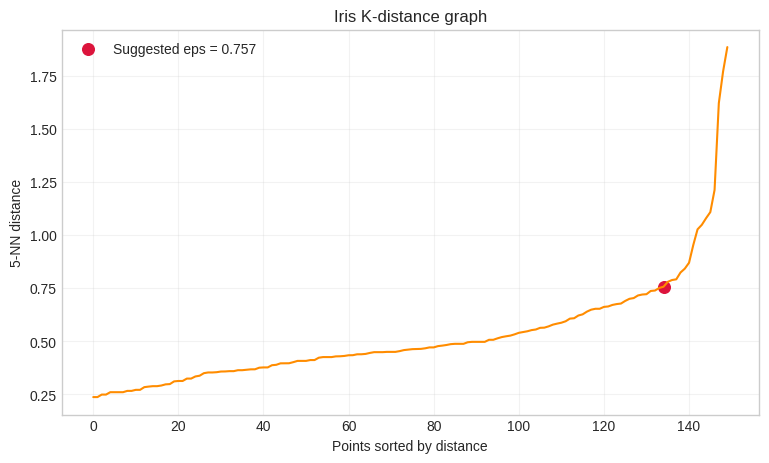

,model,cluster_count,noise_points,silhouette_score,eps
0,DBSCAN eps=0.416,5,63,0.0619,0.416
1,DBSCAN eps=0.492,2,36,0.3419,0.492
2,DBSCAN eps=0.568,2,29,0.3880,0.568
3,DBSCAN eps=0.643,2,15,0.4741,0.643
4,DBSCAN eps=0.719,2,6,0.5234,0.719
5,DBSCAN eps=0.795,2,4,0.5217,0.795
6,DBSCAN eps=0.87,2,4,0.5217,0.870
7,DBSCAN eps=0.946,2,4,0.5217,0.946
8,DBSCAN eps=1.022,2,3,0.5383,1.022
9,DBSCAN eps=1.097,2,2,0.5518,1.097


In [8]:
# DBSCAN requires an 'eps' parameter. We use the K-nearest neighbors 'elbow' method to find it.
min_samples_iris = X_iris_scaled.shape[1] + 1

nn_model_iris = NearestNeighbors(n_neighbors=min_samples_iris)
distances_iris, _ = nn_model_iris.fit(X_iris_scaled).kneighbors(X_iris_scaled)
k_distances_iris = np.sort(distances_iris[:, -1])

# Identify the 'elbow' where the distance starts to increase sharply
suggested_eps_iris, elbow_index_iris = estimate_eps_from_k_distance(k_distances_iris)

plt.figure(figsize=(9, 5))
plt.plot(k_distances_iris, color="darkorange")
plt.scatter(
    elbow_index_iris,
    k_distances_iris[elbow_index_iris],
    color="crimson",
    s=70,
    label=f"Suggested eps = {suggested_eps_iris:.3f}",
)
plt.title("Iris K-distance graph")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{min_samples_iris}-NN distance")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# Grid search around the suggested epsilon to find the optimal silhouette score
eps_candidates_iris = np.unique(
    np.round(
        np.linspace(
            max(0.10, suggested_eps_iris * 0.55),
            suggested_eps_iris * 1.45,
            10,
        ),
        3,
    )
)

search_rows_iris = []
for eps in eps_candidates_iris:
    labels = DBSCAN(eps=float(eps), min_samples=min_samples_iris).fit_predict(X_iris_scaled)
    row, _ = describe_clustering(X_iris_scaled, labels, model_name=f"DBSCAN eps={eps}")
    row["eps"] = float(eps)
    search_rows_iris.append(row)

dbscan_search_iris = pd.DataFrame(search_rows_iris)
display(dbscan_search_iris.sort_values(by="eps"))

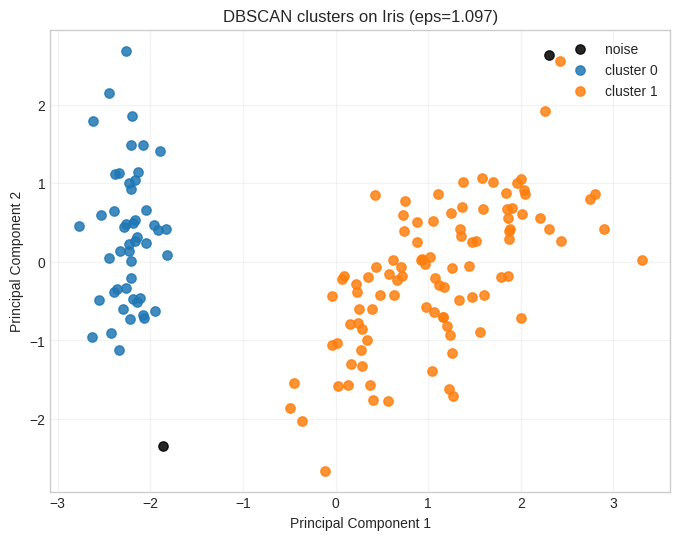

Chosen eps: 1.097
Total noise points found: 2


,model,cluster_count,noise_points,silhouette_score
0,"DBSCAN (eps=1.097, min_samples=5)",2,2,0.5518


,cluster_label,sample_silhouette
0,0,0.7740
1,0,0.6467
2,0,0.7319
3,0,0.6866
4,0,0.7663
5,0,0.6416
6,0,0.7453
7,0,0.7742
8,0,0.5788
9,0,0.6960


,sample_silhouette
count,150.0000
mean,0.5518
std,0.1868
min,-0.5773
25%,0.4845
50%,0.5786
75%,0.6497
max,0.7742


In [9]:
valid_dbscan_iris = dbscan_search_iris.dropna(subset=["silhouette_score"]).copy()
valid_dbscan_iris = valid_dbscan_iris[valid_dbscan_iris["cluster_count"] >= 2].copy()

best_dbscan_iris = valid_dbscan_iris.sort_values(
    by=["silhouette_score", "noise_points"],
    ascending=[False, True],
).iloc[0]

best_eps_iris = float(best_dbscan_iris["eps"])
dbscan_iris = DBSCAN(eps=best_eps_iris, min_samples=min_samples_iris)
dbscan_iris_labels = dbscan_iris.fit_predict(X_iris_scaled)

dbscan_iris_row, dbscan_iris_sample_scores = describe_clustering(
    X_iris_scaled,
    dbscan_iris_labels,
    model_name=f"DBSCAN (eps={best_eps_iris:.3f}, min_samples={min_samples_iris})",
)

plt.figure(figsize=(8, 6))
plot_cluster_map(
    X_iris_pca,
    dbscan_iris_labels,
    title=f"DBSCAN clusters on Iris (eps={best_eps_iris:.3f})",
    x_label="Principal Component 1",
    y_label="Principal Component 2",
)
plt.show()

print("Chosen eps:", round(best_eps_iris, 3))
print("Total noise points found:", dbscan_iris_row["noise_points"])

dbscan_iris_silhouette_df = pd.DataFrame(
    {
        "cluster_label": dbscan_iris_labels,
        "sample_silhouette": dbscan_iris_sample_scores,
    }
)

display(pd.DataFrame([dbscan_iris_row]))
display(dbscan_iris_silhouette_df.head(10))
display(dbscan_iris_silhouette_df["sample_silhouette"].describe())


In [10]:
# Final comparison of all models: which one grouped the flowers most distinctly?
iris_comparison = pd.concat(
    [
        hierarchical_results_iris,
        pd.DataFrame([dbscan_iris_row]),
    ],
    ignore_index=True,
).sort_values(by="silhouette_score", ascending=False)

display(iris_comparison)

,model,cluster_count,noise_points,silhouette_score
4,"DBSCAN (eps=1.097, min_samples=5)",2,2,0.5518
0,Hierarchical - single,3,0,0.5046
1,Hierarchical - average,3,0,0.4803
2,Hierarchical - complete,3,0,0.4496
3,Hierarchical - ward,3,0,0.4467
